# Eulers metode

## Vi illustrerer Eulers på jordens bane rundt solen. 

- Vi forenkler til at massesenteret er origo for koordinatsystemet.
- Vi jobber med et $2$-dimensjonalt koordinatsystem.
- Gravitasjonsloven til Newton sier at størrelsen til tyngdekraften er $$G\frac{mM}{r^2}$$
der $r$ er avstanden mellom jorden og origo.
- Ved å endre enheter forenkler vi formelen for størrelsen til tyngdekraften til $$\frac{m}{r^2}$$

- Skriver vi
$$\vec {\mathbf{p}}(t) = \begin{bmatrix} x(t) \\ y(t) \end{bmatrix}$$
for posisjonen av jorden til tid $t$ er $r = |\vec {\mathbf{p}}(t)|$ og tyngdekraften er
$$\vec{\mathbf{F}}(t) = -\frac{\vec {\mathbf{p}}(t)}{|\vec {\mathbf{p}}(t)|} \, \frac{m}{r^2} = \frac{- m \vec {\mathbf{p}}(t)}{r^3}.$$

Newtons gravitasjonslov sier at 
$$\vec{\mathbf{F}}(t) = m \vec {\mathbf{p}}''(t).$$

Det vil si at 
$$m {\mathbf{p}}''(t) = \frac{- m \vec P(t)}{r^3} = \frac{-m}{(x(t)^2 + y(t)^2)^{3/2}}\begin{bmatrix} x(t) \\ y(t)\end{bmatrix}.$$
slik at 
$${\mathbf{p}}''(t) = \frac{-1}{(x(t)^2 + y(t)^2)^{3/2}}\begin{bmatrix} x(t) \\ y(t)\end{bmatrix}.$$

Skriver vi $$\vec{\mathbf{p}}'(t) = \begin{bmatrix} u(t) \\ v(t) \end{bmatrix}$$

har vi
$$\begin{bmatrix} x'(t) \\ y'(t) \end{bmatrix} = \begin{bmatrix} u(t) \\ v(t) \end{bmatrix}$$
og 
$$\begin{bmatrix} u'(t) \\ v'(t) \end{bmatrix} = {\mathbf{p}}''(t) = \frac{-1}{(x(t)^2 + y(t)^2)^{3/2}}\begin{bmatrix} x(t) \\ y(t)\end{bmatrix}.$$

## Oppgave

Bruk Eulers metode til numerisk å løse dette systemet av differensialligninger for $t$ i intervallet $[0, 20]$ og for startbetingelsene
$x_0 = 2$, $y_0 = 0$, $u_0 = 0$ og $v_0 = 0.68$. Hvilken effekt ser du av antallet av steg i Eulers metode?

## Ideen i Eulers metode:

Gitt $x$, $y$, $u$ og $v$-verdiene til tid $t_i$ lar vi $x$-verdien til tid $t_{i+1} = t_i + \Delta_t$ være 
$$x(t_{i+1}) = x(t_i) + \Delta_t \cdot f(t, x(t_i), y(t_i), u(t_i), v(t_i)).$$ 

I situasjonen over er $f(t, x, y, u, v) = u$.

### Hint:

Vi kan bygge videre på Eulers metode fra forelesningen. Uheldigvis har vi her et system av fire ligninger, så koden må endres!

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def euler_method(f, g, h, k, t0, tn, x0, y0, u0, v0, n):
  """
  Anvender Eulers metode for å løse
    differensialligningen x' = f(t, x, y, u, v) og y' = g(t, x, y, u, v).
                          u' = h(t, x, y, u, v) og v' = k(t, x, y, u, v).

  Args:
    f: Funksjonen som representerer x-delen av høyre side av differensialligningen.
    g: Funksjonen som representerer y-delen av høyre side av differensialligningen.
    h: Funksjonen som representerer u-delen av høyre side av differensialligningen.
    k: Funksjonen som representerer v-delen av høyre side av differensialligningen.
    t0: Startverdien for t.
    tn: Sluttverdien for t.
    x0: Startverdien for x.
    y0: Startverdien for y.
    u0: Startverdien for u.
    v0: Startverdien for v.
    n: Antall steg.

  Returns:
    En NumPy array som inneholder de approksimerte verdiene for x i hvert steg,
    En NumPy array som inneholder de approksimerte verdiene for y i hvert steg,
    En NumPy array som inneholder de approksimerte verdiene for u i hvert steg,
    En NumPy array som inneholder de approksimerte verdiene for v i hvert steg,
  """

  # Lager en array med t-verdier fra t0 til tn med n+1 punkter
  t_values = np.linspace(t0, tn, n + 1)
  # Initialiserer listene for x- og y-verdiene med startverdiene
  x_values = [x0]

  # linjen under er ny
  y_values = [y0]
  u_values = [u0]
  v_values = [v0]

  # Beregner steglengden
  delta_t = t_values[1] - t_values[0]

  # Gjennomfører Eulers metode for hvert steg
  for i in range(n):
    # Beregner neste x-verdi
    x_next = x_values[-1] + delta_t * f(t_values[i], x_values[-1], y_values[-1], u_values[-1], v_values[-1])

    # de to linjene under er nye
    # Beregner neste y-verdi
    y_next = y_values[-1] + delta_t * g(t_values[i], x_values[-1], y_values[-1], u_values[-1], v_values[-1])
    u_next = u_values[-1] + delta_t * h(t_values[i], x_values[-1], y_values[-1], u_values[-1], v_values[-1])
    v_next = v_values[-1] + delta_t * k(t_values[i], x_values[-1], y_values[-1], u_values[-1], v_values[-1])

    # Legger til de nye verdiene i listene
    x_values.append(x_next)

    # linjen under er ny
    y_values.append(y_next)
    u_values.append(u_next)
    v_values.append(v_next)

  # Returnerer t-verdiene og de beregnede x- og y-verdiene som NumPy arrays
  return t_values, np.array(x_values), np.array(y_values), np.array(u_values), np.array(v_values)

In [4]:
def f(t, x, y, u, v):
    return u

def g(t, x, y, u, v):
    return v

def h(t, x, y, u, v):
    r = np.sqrt(x**2 + y**2)
    return # sett inn formel her

def k(t, x, y, u, v):
    r = np.sqrt(x**2 + y**2)
    return # sett inn formel her

In [5]:
t0 = 0
tn = 20
n = 1000
x0 = 2
y0 = 0
u0 = 0
v0 = 0.68


In [7]:
t, x, y, u, v = euler_method(f, g, h, k, t0, tn, x0, y0, u0, v0, n)

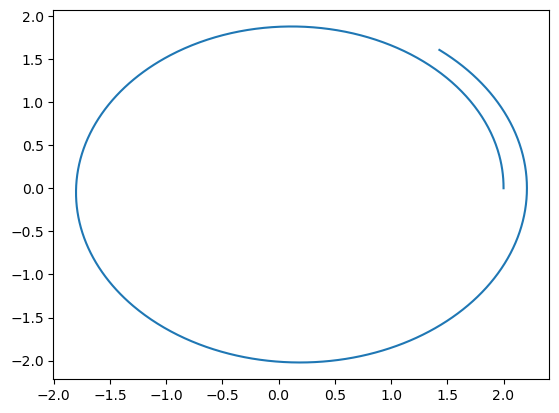

In [8]:
plt.plot(x, y)